# Correlation Breakdown in Stressed Markets: Is Crypto Contagion Real?

**Question:** Traders say that "in a crash, all correlations go to one" — diversification disappears exactly when it is needed. Crypto seems like the extreme case: when Bitcoin falls, everything falls. But Boyer, Gibson & Loretan (1997) and Forbes & Rigobon (2002) showed that a correlation measured on volatile days is *mechanically* higher than one measured on calm days, even when the true relationship has not changed at all. So how much of crypto's crash-day correlation is real, and how much is a statistical artifact?

This notebook:
1. Loads daily Binance prices for the same 8 coins as the Mean-Variance notebook.
2. Looks at how the average correlation moves with Bitcoin's volatility.
3. Runs the naive test — correlation on calm days vs big-move days — and finds an apparent "breakdown".
4. Shows with a simulation why that test is biased: conditioning on large moves raises correlation even when it is constant.
5. Applies the Forbes–Rigobon correction for that bias.
6. Separates crashes from rallies with exceedance correlations (Longin & Solnik 2001; Ang & Chen 2002), which the volatility correction cannot explain away.
7. Measures what all this does to the diversification of an equal-weight crypto portfolio.

*Inspired by WQU MScFE 560, Module 3 (Correlation): correlations in stressed markets (Loretan & English, 2000).*

In [1]:
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3})
RNG = np.random.default_rng(42)
ANN = 365   # crypto trades every day of the year

## 1. Data

`src/data.py` downloads daily candles from Binance through [ccxt](https://github.com/ccxt/ccxt) for a fixed date range, so every run sees the same history. If the download fails (no network), the cell falls back to the CSVs already in `src/data/`. We use daily close-to-close simple returns from 2021-01-01, the same universe and window as the Mean-Variance notebook. Bitcoin is the reference asset: "stress" below always means stress in BTC.

In [2]:
# src/ sits next to the topic folders: one level up in the repo, two levels up locally (W*/<Topic>/)
SRC = next(p / "src" for p in Path.cwd().resolve().parents if (p / "src" / "data.py").exists())
SYMBOLS = ["BTC/USDT", "ETH/USDT", "BNB/USDT", "SOL/USDT",
           "XRP/USDT", "ADA/USDT", "DOGE/USDT", "LINK/USDT"]
START, END = "2021-01-01", "2026-10-01"

cmd = [sys.executable, str(SRC / "data.py"), *SYMBOLS, "--since", START, "--until", END, "--full"]
result = subprocess.run(cmd, capture_output=True, text=True)
print("Downloaded from Binance" if result.returncode == 0 else "Download failed, using existing CSVs in src/data")


def load_close(symbol):
    path = SRC / "data" / f"BINANCE_{symbol.replace('/', '-')}_1d.csv"
    df = pd.read_csv(path, parse_dates=["Date"], index_col="Date")
    return df["Close"].rename(symbol.split("/")[0])


prices = pd.concat([load_close(s) for s in SYMBOLS], axis=1).loc[START:END].dropna()
returns = prices.pct_change().dropna()
names = list(returns.columns)
alts = [n for n in names if n != "BTC"]
print(f"{len(names)} assets, {len(returns)} daily returns: {returns.index[0].date()} → {returns.index[-1].date()}")

Downloaded from Binance
8 assets, 2098 daily returns: 2021-01-02 → 2026-09-30


## 2. First look: correlation moves with volatility

Two rolling series: the **average pairwise correlation** of the eight coins over the past 60 days, and Bitcoin's **30-day annualized volatility**. If the folk wisdom is right, the first should rise when the second does.

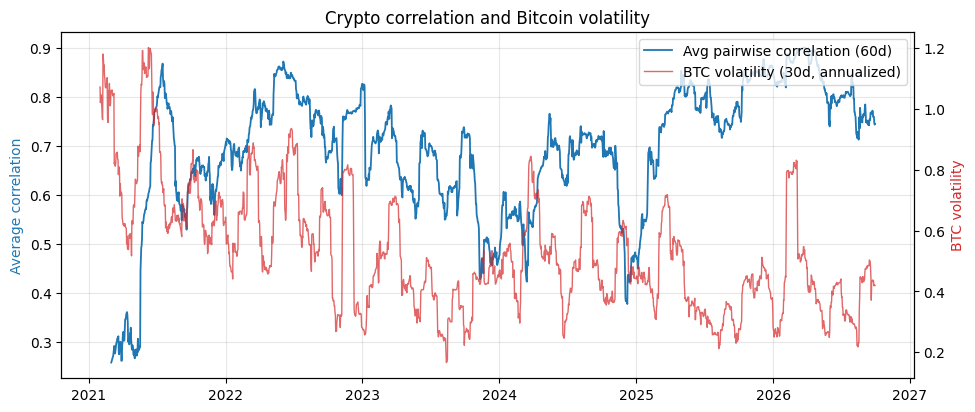

Correlation between the two series: -0.15
Average pairwise correlation: min 0.26, median 0.71, max 0.90


In [3]:
def avg_pairwise_corr(window):
    c = window.corr().values
    return c[np.triu_indices_from(c, k=1)].mean()


avg_corr = pd.Series([avg_pairwise_corr(returns.iloc[i - 60:i]) for i in range(60, len(returns) + 1)],
                     index=returns.index[59:])
btc_vol = returns["BTC"].rolling(30).std() * np.sqrt(ANN)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(avg_corr, color="tab:blue", lw=1.3, label="Avg pairwise correlation (60d)")
ax1.set_ylabel("Average correlation", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(btc_vol, color="tab:red", lw=1, alpha=0.7, label="BTC volatility (30d, annualized)")
ax2.set_ylabel("BTC volatility", color="tab:red")
ax2.grid(False)
ax1.set_title("Crypto correlation and Bitcoin volatility")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.show()

both = pd.concat([avg_corr, btc_vol], axis=1).dropna()
print(f"Correlation between the two series: {both.iloc[:, 0].corr(both.iloc[:, 1]):.2f}")
print(f"Average pairwise correlation: min {avg_corr.min():.2f}, median {avg_corr.median():.2f}, max {avg_corr.max():.2f}")

The picture does **not** match the folk wisdom. Over 60-day windows, average correlation and Bitcoin's volatility are slightly *negatively* related (about −0.15). The low point, early 2021, came during the most volatile stretch in the sample — the "altcoin season", when DOGE, SOL and ADA rallied on their own stories and decoupled from BTC. Correlation then climbed through the 2022 bear market and has stayed high (mostly 0.7–0.9) since 2025, while BTC's volatility drifted *down*.

So the slow-moving level of crypto correlation is driven more by market structure — whether coins trade on their own news or as one "crypto beta" — than by volatility. The folk claim is really about the short run: *on the day of a crash*, do coins move together more? That needs a day-level test.

## 3. The naive test: calm days vs big-move days

The simplest test of "correlations rise in a crisis": split the sample by how big Bitcoin's move was that day, and compute each coin's correlation with BTC separately on calm and stress days.

In [4]:
# Split days by the size of Bitcoin's move: the top 10% of |r_BTC| are "stress" days
big = returns["BTC"].abs() > returns["BTC"].abs().quantile(0.90)
calm, stress = returns[~big], returns[big]


def corr_with_btc(df):
    return df[alts].corrwith(df["BTC"])


naive = pd.DataFrame({"Calm days": corr_with_btc(calm), "Stress days": corr_with_btc(stress)})
naive["Change"] = naive["Stress days"] - naive["Calm days"]
print(f"{(~big).sum()} calm days, {big.sum()} stress days (|BTC return| > {returns['BTC'].abs().quantile(0.9):.1%})")
display(naive.style.format("{:+.2f}", subset=["Change"]).format("{:.2f}", subset=["Calm days", "Stress days"]))

1888 calm days, 210 stress days (|BTC return| > 4.7%)


,Calm days,Stress days,Change
ETH,0.72,0.91,+0.19
BNB,0.53,0.75,+0.23
SOL,0.54,0.72,+0.19
XRP,0.46,0.80,+0.34
ADA,0.57,0.77,+0.20
DOGE,0.41,0.38,-0.03
LINK,0.58,0.85,+0.26


Taken at face value, this is a textbook correlation breakdown. On the 210 days when BTC moved more than about 4.7%, six of the seven alts were much more correlated with it — XRP from 0.46 to 0.80, ETH from 0.72 to 0.91 — and every one of those increases is highly significant (next section). DOGE is the exception, most likely because many of its largest moves in this window (the 2021 social-media rallies) came from its own news rather than from Bitcoin.

The next section shows why this result cannot be taken at face value.

## 4. Why the naive test is biased

Take two assets with a *constant* linear relationship, $y = \beta x + \varepsilon$, where $\varepsilon$ is independent of $x$. The correlation is

$$ \rho = \frac{\beta\,\sigma_x}{\sqrt{\beta^2\sigma_x^2 + \sigma_\varepsilon^2}}. $$

Nothing about the relationship ($\beta$, $\sigma_\varepsilon$) has changed on a stress day, but $\sigma_x$ — the variance of the asset we conditioned on — is larger. A bigger $\sigma_x$ means the common component $\beta x$ dominates the idiosyncratic noise $\varepsilon$, so the *measured* correlation rises. Boyer, Gibson & Loretan (1997) give the exact formula: if $\delta = \sigma^2_{x,\text{stress}} / \sigma^2_{x,\text{calm}} - 1$ is the relative increase in the conditioning asset's variance, then

$$ \rho_{\text{stress}} = \rho \sqrt{\frac{1 + \delta}{1 + \delta\rho^2}} \;>\; \rho. $$

The simulation below draws 500,000 days from a bivariate normal with a **fixed** $\rho = 0.5$, then keeps only the days on which $|x|$ exceeds a threshold — exactly what Section 3 did.

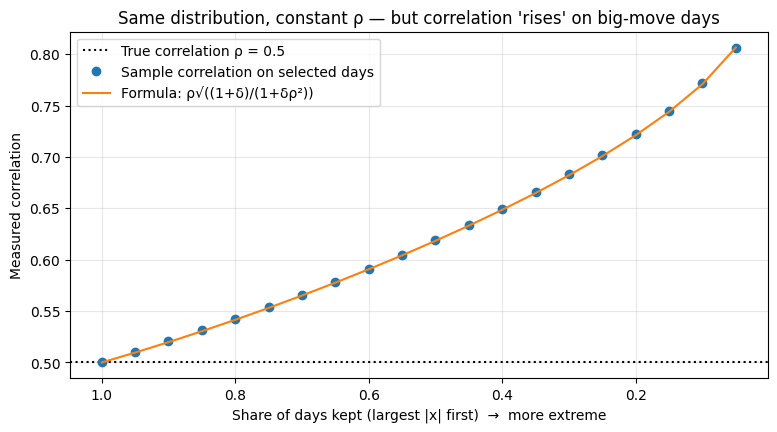

Keeping only the 5% largest |x| days: measured correlation 0.81 vs true 0.5


In [5]:
rho_true, n_sim = 0.5, 500_000
x = RNG.standard_normal(n_sim)
y = rho_true * x + np.sqrt(1 - rho_true**2) * RNG.standard_normal(n_sim)

quantiles = np.linspace(0, 0.95, 20)
rows = []
for q in quantiles:
    sel = np.abs(x) > np.quantile(np.abs(x), q)
    delta = x[sel].var() / x.var() - 1
    theory = rho_true * np.sqrt((1 + delta) / (1 + delta * rho_true**2))
    rows.append((q, np.corrcoef(x[sel], y[sel])[0, 1], theory))
sim = pd.DataFrame(rows, columns=["q", "sample", "theory"])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(rho_true, color="k", ls=":", label=f"True correlation ρ = {rho_true}")
ax.plot(1 - sim["q"], sim["sample"], "o", color="tab:blue", label="Sample correlation on selected days")
ax.plot(1 - sim["q"], sim["theory"], "-", color="tab:orange", label="Formula: ρ√((1+δ)/(1+δρ²))")
ax.invert_xaxis()
ax.set_xlabel("Share of days kept (largest |x| first)  →  more extreme")
ax.set_ylabel("Measured correlation")
ax.set_title("Same distribution, constant ρ — but correlation 'rises' on big-move days")
ax.legend()
plt.show()
print(f"Keeping only the 5% largest |x| days: measured correlation {sim['sample'].iloc[-1]:.2f} vs true {rho_true}")

The measured correlation climbs from 0.5 to above 0.8 on the most extreme days, although the data were generated with one constant correlation. Any test that compares correlations across volatility regimes without correcting for this will find a "breakdown" in data that has none.

## 5. The Forbes–Rigobon correction

Inverting the formula above gives the heteroskedasticity-adjusted correlation of Forbes & Rigobon (2002):

$$ \rho^{*} = \frac{\rho_{\text{stress}}}{\sqrt{1 + \delta\,(1 - \rho_{\text{stress}}^2)}}. $$

$\rho^*$ is what the stress-day correlation *would be* if the underlying relationship were unchanged and only Bitcoin's volatility had risen. If $\rho^*$ is still clearly above the calm-day correlation, the linkage itself has strengthened — Forbes & Rigobon call that **contagion**. If not, the high crash-day correlation is just the usual **interdependence**, amplified by volatility. The test below compares the two with Fisher's $z$-transform.

BTC variance on stress days is 15.8× its calm-day variance (delta = 14.8)


,Calm,Stress (raw),Stress (adjusted),p raw > calm,p adj > calm
ETH,0.72,0.91,0.49,0.000,1.000
BNB,0.53,0.75,0.28,0.000,1.000
SOL,0.54,0.72,0.25,0.000,1.000
XRP,0.46,0.80,0.31,0.000,0.989
ADA,0.57,0.77,0.29,0.000,1.000
DOGE,0.41,0.38,0.10,0.714,1.000
LINK,0.58,0.85,0.38,0.000,1.000


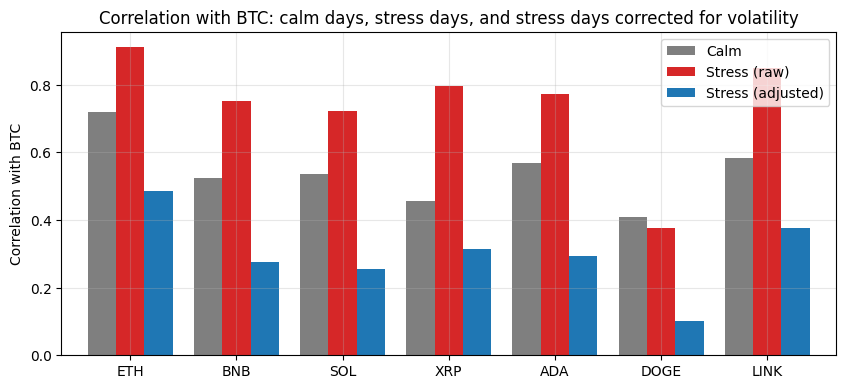

In [6]:
delta = stress["BTC"].var() / calm["BTC"].var() - 1
adjusted = naive["Stress days"] / np.sqrt(1 + delta * (1 - naive["Stress days"]**2))


def fisher_z_test(r1, n1, r2, n2):
    # one-sided p-value for H1: r1 > r2
    z = (np.arctanh(r1) - np.arctanh(r2)) / np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    return 1 - stats.norm.cdf(z)


fr = pd.DataFrame({
    "Calm": naive["Calm days"],
    "Stress (raw)": naive["Stress days"],
    "Stress (adjusted)": adjusted,
    "p raw > calm": fisher_z_test(naive["Stress days"], big.sum(), naive["Calm days"], (~big).sum()),
    "p adj > calm": fisher_z_test(adjusted, big.sum(), naive["Calm days"], (~big).sum()),
})
print(f"BTC variance on stress days is {1 + delta:.1f}× its calm-day variance (delta = {delta:.1f})")
display(fr.style.format("{:.2f}").format("{:.3f}", subset=["p raw > calm", "p adj > calm"]))

ax = fr[["Calm", "Stress (raw)", "Stress (adjusted)"]].plot.bar(figsize=(10, 4.2), width=0.8,
                                                               color=["tab:gray", "tab:red", "tab:blue"])
ax.set_ylabel("Correlation with BTC")
ax.set_title("Correlation with BTC: calm days, stress days, and stress days corrected for volatility")
plt.xticks(rotation=0)
plt.show()

After the correction the "breakdown" disappears. Every adjusted stress-day correlation is *below* its calm-day level, so there is no evidence of contagion in the Forbes–Rigobon sense: the strong co-movement on big BTC days is what you would expect from the ordinary, everyday dependence of alts on Bitcoin, magnified by Bitcoin's 16-times-larger variance on those days.

The adjusted numbers are not to be taken literally either. The correction assumes the alts' *own* noise ($\sigma_\varepsilon$) is the same on calm and stress days. In crypto it is not — on a day BTC falls 10%, alts also carry larger idiosyncratic shocks — so with a $\delta$ this large the formula over-corrects, and the adjusted values (0.1–0.5) are below any plausible "true" correlation. The honest reading is a bound: the true stress-day linkage lies somewhere between the adjusted and the raw values, and the data cannot reject that it is the same as on calm days. The volatility effect is large enough to explain the whole naive jump on its own.

## 6. Crashes vs rallies: exceedance correlation

Sections 3–5 treated a +12% day and a −12% day alike. Longin & Solnik (2001) and Ang & Chen (2002) separate them with the **exceedance correlation**: standardize each return to $z$-scores, and for a threshold $\theta \ge 0$ compute

$$ \rho^-(\theta) = \text{corr}(x, y \mid x < -\theta,\; y < -\theta), \qquad \rho^+(\theta) = \text{corr}(x, y \mid x > \theta,\; y > \theta). $$

$\rho^-$ looks only at days when *both* coins fell by more than $\theta$ standard deviations; $\rho^+$ only at days when both rose. For a bivariate normal, the two curves are mirror images and both fall towards zero as $\theta$ grows — so the volatility bias of Section 4 cannot make crashes look different from rallies. The dashed line is that normal benchmark, simulated with the same overall correlation as the data.

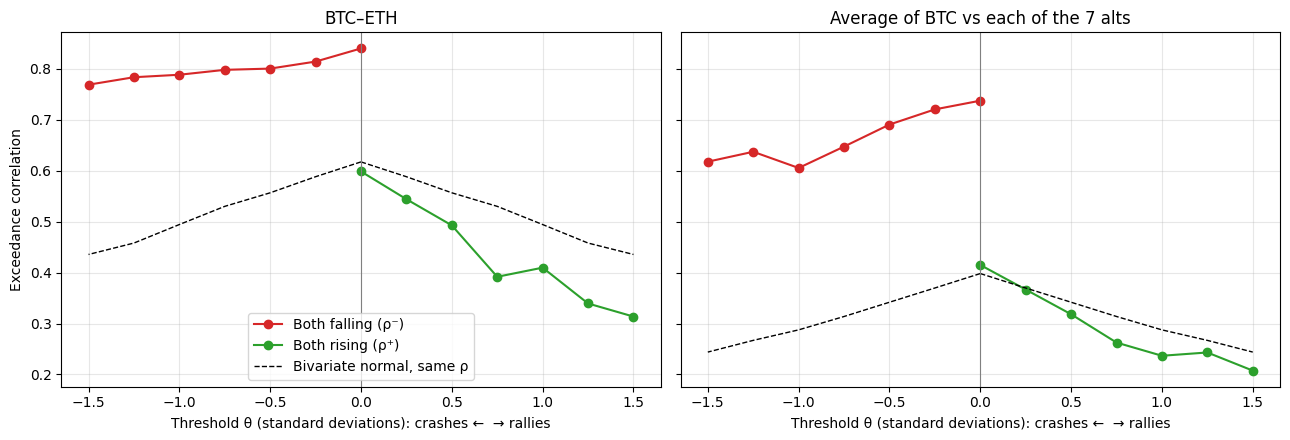

,ρ⁻ (θ=1),ρ⁺ (θ=1),Normal (θ=1),Down − up
ETH,0.79,0.41,0.49,0.38
BNB,0.69,0.16,0.28,0.53
SOL,0.61,0.40,0.27,0.22
XRP,0.57,-0.05,0.24,0.62
ADA,0.54,0.19,0.29,0.35
DOGE,0.42,0.16,0.11,0.25
LINK,0.62,0.39,0.33,0.23


In [7]:
thetas = np.arange(0, 1.51, 0.25)
z = (returns - returns.mean()) / returns.std()


def exceedance(xz, yz, theta, side):
    sel = (xz < -theta) & (yz < -theta) if side == "down" else (xz > theta) & (yz > theta)
    return np.corrcoef(xz[sel], yz[sel])[0, 1] if sel.sum() > 20 else np.nan


def normal_exceedance(rho, theta, n=400_000):
    xs = RNG.standard_normal(n)
    ys = rho * xs + np.sqrt(1 - rho**2) * RNG.standard_normal(n)
    return exceedance(xs, ys, theta, "down")   # symmetric: up = down


curves = {}
for a in alts:
    rho_a = returns["BTC"].corr(returns[a])
    curves[a] = pd.DataFrame({
        "down": [exceedance(z["BTC"].values, z[a].values, t, "down") for t in thetas],
        "up": [exceedance(z["BTC"].values, z[a].values, t, "up") for t in thetas],
        "normal": [normal_exceedance(rho_a, t) for t in thetas],
    }, index=thetas)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (title, df) in zip(axes, [("BTC–ETH", curves["ETH"]),
                                  ("Average of BTC vs each of the 7 alts", pd.concat(curves.values()).groupby(level=0).mean())]):
    ax.plot(-df.index, df["down"], "o-", color="tab:red", label="Both falling (ρ⁻)")
    ax.plot(df.index, df["up"], "o-", color="tab:green", label="Both rising (ρ⁺)")
    ax.plot(-df.index, df["normal"], "k--", lw=1, label="Bivariate normal, same ρ")
    ax.plot(df.index, df["normal"], "k--", lw=1)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlabel("Threshold θ (standard deviations): crashes ←  → rallies")
    ax.set_title(title)
axes[0].set_ylabel("Exceedance correlation")
axes[0].legend(loc="lower center")
plt.tight_layout()
plt.show()

summary = pd.DataFrame({a: {"ρ⁻ (θ=1)": c.loc[1.0, "down"], "ρ⁺ (θ=1)": c.loc[1.0, "up"],
                            "Normal (θ=1)": c.loc[1.0, "normal"]} for a, c in curves.items()}).T
summary["Down − up"] = summary["ρ⁻ (θ=1)"] - summary["ρ⁺ (θ=1)"]
display(summary.style.format("{:.2f}"))

Here the data clearly depart from the normal benchmark, and in the direction the folk wisdom predicts:

* **Crashes stay correlated.** When both BTC and an alt are down more than one standard deviation, their correlation is 0.54–0.79 (0.79 for ETH). Under a normal distribution with the same overall correlation it would be only 0.11–0.49 — and it would *fall* as the threshold rises. For BTC–ETH it barely falls at all.
* **Rallies do not.** On joint up-days the correlation drops quickly, to roughly the normal benchmark or below (XRP even turns slightly negative at θ = 1). Every alt has a higher crash correlation than rally correlation, by 0.22–0.62.

This asymmetry is the part of "correlations go to one in a crash" that survives scrutiny. The volatility bias of Section 4 is symmetric — it would inflate up-days as much as down-days — so it cannot produce this pattern. It is the same result Longin & Solnik (2001) found for international stock markets and Ang & Chen (2002) for US stocks, and in crypto it is stronger: when the market sells off, it sells off as one asset; when it rallies, coins go their own way.

## 7. What it costs a portfolio

Correlations are only a means to an end; what an investor feels is how much diversification an equal-weight (1/N) basket of the eight coins actually delivers. The **diversification ratio**

$$ DR = \frac{\sum_i w_i \sigma_i}{\sigma_p} $$

is the weighted average of the coins' volatilities divided by the portfolio's volatility. $DR = 1$ means no diversification at all (every coin moves in lockstep); higher is better. We compute it on three kinds of day: calm days, Bitcoin's worst 10% of days, and Bitcoin's best 10% of days.

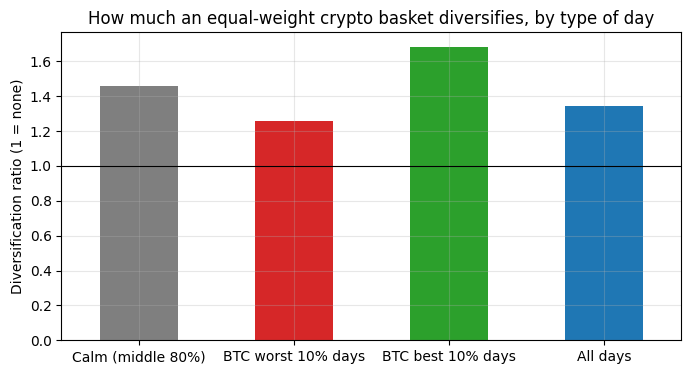

Calm (middle 80%)     1.46
BTC worst 10% days    1.26
BTC best 10% days     1.68
All days              1.34

On BTC's worst 10% days, 93% of the alts fell on average; on its best 10% days, 95% of the alts rose.


In [8]:
w = np.ones(len(names)) / len(names)


def diversification_ratio(df):
    return (w @ df.std().values) / (df.values @ w).std()


down_days = returns["BTC"] < returns["BTC"].quantile(0.10)
up_days = returns["BTC"] > returns["BTC"].quantile(0.90)
middle = ~(down_days | up_days)

dr = pd.Series({"Calm (middle 80%)": diversification_ratio(returns[middle]),
                "BTC worst 10% days": diversification_ratio(returns[down_days]),
                "BTC best 10% days": diversification_ratio(returns[up_days]),
                "All days": diversification_ratio(returns)})
share_down = (returns.loc[down_days, alts] < 0).mean(axis=1).mean()
share_up = (returns.loc[up_days, alts] > 0).mean(axis=1).mean()

ax = dr.plot.bar(figsize=(8, 4), color=["tab:gray", "tab:red", "tab:green", "tab:blue"])
ax.axhline(1, color="k", lw=0.8)
ax.set_ylabel("Diversification ratio (1 = none)")
ax.set_title("How much an equal-weight crypto basket diversifies, by type of day")
plt.xticks(rotation=0)
plt.show()
print(dr.round(2).to_string())
print(f"\nOn BTC's worst 10% days, {share_down:.0%} of the alts fell on average; "
      f"on its best 10% days, {share_up:.0%} of the alts rose.")

The equal-weight basket diversifies least exactly when it matters most. On Bitcoin's worst 10% of days its diversification ratio falls to 1.26, against 1.46 on calm days and 1.68 on Bitcoin's best days. On a typical crash day 93% of the alts fall with BTC.

For an investor this is the practical translation of Section 6. A risk model calibrated on all days (DR 1.34) overstates the protection available in a sell-off, and understates it in a rally — the wrong way round for anyone who cares about drawdowns. It also explains why, in the Mean-Variance notebook, the optimizer found so little to gain from adding alts to BTC.

## 8. Takeaways

1. **The naive evidence for "correlation breakdown" is mostly a statistical artifact.** Splitting the sample by the size of Bitcoin's move raises measured correlations even when the true relationship is constant (Boyer, Gibson & Loretan 1997). The simulation reproduced a jump from 0.5 to 0.8 with no change in the data-generating process.
2. **Corrected for volatility, there is no evidence of contagion.** The Forbes–Rigobon adjustment removes the whole calm-to-stress increase for every coin. With crypto's fat tails it over-corrects, so the right conclusion is "no evidence of a stronger linkage", not "a weaker linkage".
3. **The asymmetry is real.** Exceedance correlations show that coins fall together much more than they rise together — far beyond what a normal distribution allows, and in a pattern volatility cannot explain. This is the part of the folk wisdom that holds.
4. **Diversification within crypto is weakest in sell-offs.** An equal-weight basket's diversification ratio drops from 1.46 on calm days to 1.26 on Bitcoin's worst days. Risk models that use one correlation matrix for all days overstate downside protection.
5. **The level of correlation is a regime, not a constant.** Average crypto correlation ranged from 0.26 to 0.90 over 2021–2026, driven more by market structure than by volatility. Any portfolio built on a single historical correlation matrix should be stress-tested against the high-correlation regime.

**Next steps:** model the asymmetry directly with a dynamic conditional correlation (DCC-GARCH) model or a copula with lower-tail dependence (e.g. Clayton), and add assets outside crypto (equities, gold) to see whether *cross-asset* diversification survives sell-offs better than diversification within crypto.

## References

* Boyer, B. H., Gibson, M. S., Loretan, M. (1997). Pitfalls in Tests for Changes in Correlations. *Federal Reserve IFDP* 597.
* Loretan, M., English, W. B. (2000). Evaluating "Correlation Breakdowns" during Periods of Market Volatility. *Federal Reserve IFDP* 658.
* Forbes, K. J., Rigobon, R. (2002). No Contagion, Only Interdependence: Measuring Stock Market Comovements. *Journal of Finance* 57(5), 2223–2261.
* Longin, F., Solnik, B. (2001). Extreme Correlation of International Equity Markets. *Journal of Finance* 56(2), 649–676.
* Ang, A., Chen, J. (2002). Asymmetric Correlations of Equity Portfolios. *Journal of Financial Economics* 63(3), 443–494.